In [1]:
import ssl

ssl._create_default_https_context = ssl._create_stdlib_context

In [2]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [3]:
# Retrieve the data
ERA5 = xr.open_dataset(Path() / "data" / "era5-uv" / "data.nc")
ERA5 = ERA5.sel(valid_time="2024-04-02T12:00:00", pressure_level=500)

In [4]:
# Since numcodecs-safeguards only supports single-variable safeguarding, we
# stack the u and v variables into a combined variable.
ERA5_UV = np.stack([ERA5["u"].values, ERA5["v"].values], axis=0)
ERA5.u.dims, ERA5_UV.shape

(('latitude', 'longitude'), (2, 721, 1440))

In [5]:
eb_abs = 0.01

In [6]:
from numcodecs_wasm_zfp import Zfp

zfp = Zfp(mode="fixed-accuracy", tolerance=eb_abs)

In [7]:
vor_eb_abs = 1e-8

In [8]:
from compression_safeguards import SafeguardKind

qoi_eb_stencil = SafeguardKind.qoi_eb_stencil.value(
    qoi="""
    V["earth_radius"] = 6371000;  # [m], globally averaged

    # extract u and v from the first stacked dimension
    V["u"] = X[0, I[1], I[2]];
    V["v"] = X[1, I[1], I[2]];
    # convert latitude in degrees to radians
    V["latRad"] = c["lat"] * pi / 180;

    # approximate the spatial derivatives with finite differences
    # (1) along the latitude axis, we need to handle the polar boundary
    V["dUdTheta"] = where(
        abs(c["lat"]) < 90,
        # use central difference where possible
        finite_difference(
            V["u"] * cos(V["latRad"]),
            order=1, accuracy=2, type=0, axis=1,
            grid_centre=c["lat"],
        ),
        # at the poles, use forward/backwards difference
        where(
            c["lat"] == -90,
            finite_difference(
                V["u"] * cos(V["latRad"]),
                order=1, accuracy=1, type=-1, axis=1,
                grid_centre=c["lat"],
            ),
            finite_difference(
                V["u"] * cos(V["latRad"]),
                order=1, accuracy=1, type=+1, axis=1,
                grid_centre=c["lat"],
            ),
        ),
    );
    # (2) along the longitude axis, we handle the 360 degree periodic boundary
    V["dVdPhi"] = finite_difference(
        V["v"],
        order=1, accuracy=2, type=0, axis=2,
        grid_centre=c["lon"], grid_period=360,
    );

    # compute the relative vorticity
    return (V["dVdPhi"] - V["dUdTheta"]) / (
        V["earth_radius"] * cos(V["latRad"])
    );
    """,
    type="abs",
    eb=vor_eb_abs,
    neighbourhood=[
        # [u, v]: stacked variables
        dict(axis=0, before=0, after=1, boundary="valid"),
        # latitude: edge boundary is good enough (since we ensure in the QoI
        #           that the edge-extended values are not used)
        dict(axis=1, before=1, after=1, boundary="edge"),
        # longitude: wrapping boundary
        dict(axis=2, before=1, after=1, boundary="wrap"),
    ],
)

In [9]:
from numcodecs_safeguards.lossless import _default_lossless_for_corrections

In [10]:
import time

ERA5_UV_da = ERA5.to_dataarray()

In [11]:
import tracemalloc

In [12]:
from compression_safeguards.api import Safeguards

codec = zfp
pre_codec = time.perf_counter_ns()
ERA5_UV_codec = codec.decode(codec.encode(ERA5_UV))
post_codec = time.perf_counter_ns()
print(f" - Codec: {(post_codec - pre_codec) * 1e-9}")

tracemalloc.start()
pre_compute = time.perf_counter_ns()
ERA5_UV_codec_corr = Safeguards(
    safeguards=[qoi_eb_stencil],
).compute_correction(
    ERA5_UV,
    ERA5_UV_codec,
    late_bound={
        "lat": ERA5.latitude.values.reshape(1, -1, 1),
        "lon": ERA5.longitude.values.reshape(1, 1, -1),
    },
)
post_compute = time.perf_counter_ns()
compute_size, compute_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f" - Compute: {(post_compute - pre_compute) * 1e-9}")
print(f"   - Size: {compute_size}")
print(f"   - Peak: {compute_peak}")

codec = _default_lossless_for_corrections()
pre_compress = time.perf_counter_ns()
ERA5_UV_codec_corr_compressed = codec.decode(codec.encode(ERA5_UV_codec_corr))
post_compress = time.perf_counter_ns()
print(f" - Compress: {(post_compress - pre_compress) * 1e-9}")

pre_apply = time.perf_counter_ns()
ERA5_UV_codec_sg = Safeguards(
    safeguards=[qoi_eb_stencil],
).apply_correction(ERA5_UV_codec, ERA5_UV_codec_corr)
post_apply = time.perf_counter_ns()
print(f" - Apply: {(post_apply - pre_apply) * 1e-9}")

baseline = {
    "codec": (post_codec - pre_codec) * 1e-9,
    "compute": (post_compute - pre_compute) * 1e-9,
    "compute-size": compute_size,
    "compute-peak": compute_peak,
    "compress": (post_compress - pre_compress) * 1e-9,
    "apply": (post_apply - pre_apply) * 1e-9,
}

 - Codec: 2.0050131660000003
 - Compute: 13.848499166000002
   - Size: 8426921
   - Peak: 2801472271
 - Compress: 0.074202458
 - Apply: 0.000479708


In [13]:
from compression_safeguards.safeguards.stencil import (
    BoundaryCondition,
    NeighbourhoodAxis,
)

tracemalloc.start()
pre_compute = time.perf_counter_ns()
sg = Safeguards(
    safeguards=[qoi_eb_stencil],
)
ERA5_UV_check_chunk = sg.check_chunk(
    ERA5_UV,
    ERA5_UV_codec,
    data_shape=ERA5_UV.shape,
    chunk_offset=tuple(0 for _ in range(ERA5_UV.ndim)),
    chunk_stencil=tuple(
        (BoundaryCondition.valid, NeighbourhoodAxis(before=0, after=0))
        for _ in range(ERA5_UV.ndim)
    ),
    late_bound_chunk={
        "lat": ERA5.latitude.values.reshape(1, -1, 1),
        "lon": ERA5.longitude.values.reshape(1, 1, -1),
    },
    where_chunk=True,
)
ERA5_UV_single_chunk_codec_corr = Safeguards(
    safeguards=[qoi_eb_stencil],
).compute_chunked_correction(
    ERA5_UV,
    ERA5_UV_codec,
    data_shape=ERA5_UV.shape,
    chunk_offset=tuple(0 for _ in range(ERA5_UV.ndim)),
    chunk_stencil=tuple(
        (BoundaryCondition.valid, NeighbourhoodAxis(before=0, after=0))
        for _ in range(ERA5_UV.ndim)
    ),
    any_chunk_check_failed=not ERA5_UV_check_chunk,
    late_bound_chunk={
        "lat": ERA5.latitude.values.reshape(1, -1, 1),
        "lon": ERA5.longitude.values.reshape(1, 1, -1),
    },
    where_chunk=True,
)
post_compute = time.perf_counter_ns()
compute_size, compute_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f" - Compute: {(post_compute - pre_compute) * 1e-9}")
print(f"   - Size: {compute_size}")
print(f"   - Peak: {compute_peak}")

np.testing.assert_array_equal(
    ERA5_UV_single_chunk_codec_corr, ERA5_UV_codec_corr, strict=True
)

single_chunk_baseline = {
    "codec": (post_codec - pre_codec) * 1e-9,
    "compute": (post_compute - pre_compute) * 1e-9,
    "compute-size": compute_size,
    "compute-peak": compute_peak,
    "compress": (post_compress - pre_compress) * 1e-9,
    "apply": (post_apply - pre_apply) * 1e-9,
}

 - Compute: 14.063208958
   - Size: 8358048
   - Peak: 2818040090


In [14]:
import xarray_safeguards
from numcodecs.abc import Codec
from xarray.namedarray.parallelcompat import get_chunked_array_type

qoi_eb_stencil_chunked = SafeguardKind.qoi_eb_stencil.value.from_config(
    {
        k: (v.replace('"lat"', '"$d_latitude"').replace('"lon"', '"$d_longitude"'))
        if k == "qoi"
        else v
        for k, v in qoi_eb_stencil.get_config().items()
        if k != "kind"
    }
)

timings = []

for num_chunks in [
    {"variable": 1, "latitude": 1, "longitude": 1},
    {"variable": 1, "latitude": 1, "longitude": 2},
    {"variable": 1, "latitude": 2, "longitude": 4},
    {"variable": 1, "latitude": 4, "longitude": 8},
    {"variable": 1, "latitude": 8, "longitude": 16},
    {"variable": 1, "latitude": 16, "longitude": 32},
    {"variable": 1, "latitude": 32, "longitude": 64},
    # {"variable": 1, "latitude": 64, "longitude": 128},
    # {"variable": 1, "latitude": 128, "longitude": 256},
]:
    print(num_chunks)

    ERA5_UV_da_chunked = ERA5_UV_da.chunk(
        {
            "variable": (ERA5_UV_da.variable.size + num_chunks["variable"] - 1)
            // num_chunks["variable"],
            "latitude": (ERA5_UV_da.latitude.size + num_chunks["latitude"] - 1)
            // num_chunks["latitude"],
            "longitude": (ERA5_UV_da.longitude.size + num_chunks["longitude"] - 1)
            // num_chunks["longitude"],
        }
    ).rename("ERA5-uv")

    chunkmanager = get_chunked_array_type(ERA5_UV_da_chunked.data)

    def encode_decode(data: np.ndarray, codec: Codec):
        return codec.decode(codec.encode(data))

    pre_codec = time.perf_counter_ns()
    ERA5_UV_da_chunked_codec = ERA5_UV_da_chunked.copy(
        data=chunkmanager.map_blocks(
            encode_decode,
            ERA5_UV_da_chunked.data,
            dtype=ERA5_UV_da_chunked.dtype,
            chunks=None,
            codec=zfp,
        )
    ).persist(scheduler="synchronous")
    post_codec = time.perf_counter_ns()
    print(f" - Codec: {(post_codec - pre_codec) * 1e-9}")

    tracemalloc.start()
    pre_compute = time.perf_counter_ns()
    ERA5_UV_da_chunked_codec_corr = xarray_safeguards.produce_data_array_correction(
        ERA5_UV_da_chunked,
        ERA5_UV_da_chunked_codec,
        safeguards=[qoi_eb_stencil_chunked],
    ).persist(scheduler="synchronous")
    post_compute = time.perf_counter_ns()
    compute_size, compute_peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f" - Compute: {(post_compute - pre_compute) * 1e-9}")
    print(f"   - Size: {compute_size}")
    print(f"   - Peak: {compute_peak}")

    try:
        np.testing.assert_array_equal(
            ERA5_UV_da_chunked_codec_corr.values, ERA5_UV_codec_corr, strict=True
        )
    except AssertionError as err:
        print(err)

    pre_compress = time.perf_counter_ns()
    ERA5_UV_da_chunked_codec_corr_compressed = ERA5_UV_da_chunked_codec_corr.copy(
        data=chunkmanager.map_blocks(
            encode_decode,
            ERA5_UV_da_chunked_codec_corr.data,
            dtype=ERA5_UV_da_chunked_codec_corr.dtype,
            chunks=None,
            codec=_default_lossless_for_corrections(),
        )
    ).persist(scheduler="synchronous")
    post_compress = time.perf_counter_ns()
    print(f" - Compress: {(post_compress - pre_compress) * 1e-9}")

    pre_apply = time.perf_counter_ns()
    ERA5_UV_da_chunked_codec_sg = xarray_safeguards.apply_data_array_correction(
        ERA5_UV_da_chunked_codec,
        ERA5_UV_da_chunked_codec_corr,
    ).persist(scheduler="synchronous")
    post_apply = time.perf_counter_ns()
    print(f" - Apply: {(post_apply - pre_apply) * 1e-9}")

    assert Safeguards(
        safeguards=[qoi_eb_stencil],
    ).check(
        ERA5_UV_da.values,
        ERA5_UV_da_chunked_codec_sg.values,
        late_bound={
            "lat": ERA5.latitude.values.reshape(1, -1, 1),
            "lon": ERA5.longitude.values.reshape(1, 1, -1),
        },
    )

    timings.append(
        {
            "chunks": num_chunks,
            "codec": (post_codec - pre_codec) * 1e-9,
            "compute": (post_compute - pre_compute) * 1e-9,
            "compute-size": compute_size,
            "compute-peak": compute_peak,
            "compress": (post_compress - pre_compress) * 1e-9,
            "apply": (post_apply - pre_apply) * 1e-9,
        }
    )

    ERA5_dechunked_codec_sg = ERA5_UV_da_chunked_codec_sg.to_dataset(
        "variable"
    ).compute()

{'variable': 1, 'latitude': 1, 'longitude': 1}
 - Codec: 1.960582792
 - Compute: 27.760411459
   - Size: 9122225
   - Peak: 2987827525
 - Compress: 0.080879458
 - Apply: 0.019080083
{'variable': 1, 'latitude': 1, 'longitude': 2}
 - Codec: 2.098785084
 - Compute: 22.880363416
   - Size: 9806953
   - Peak: 2968965552
 - Compress: 0.073330875
 - Apply: 0.017809667
{'variable': 1, 'latitude': 2, 'longitude': 4}
 - Codec: 1.8433855840000002
 - Compute: 20.680791875
   - Size: 9514029
   - Peak: 1889959945

Arrays are not equal

Mismatched elements: 22417 / 2076480 (1.08%)
First 5 mismatches are at indices:
 [0, 437, 616]: 0 (ACTUAL), 1277165567 (DESIRED)
 [0, 491, 909]: 0 (ACTUAL), 1280311295 (DESIRED)
 [0, 719, 0]: 4294967136 (ACTUAL), 0 (DESIRED)
 [0, 719, 1]: 96 (ACTUAL), 64 (DESIRED)
 [0, 719, 2]: 4294966624 (ACTUAL), 640 (DESIRED)
Max absolute difference among violations: 2147483648
Max relative difference among violations: 2730.66666667
 ACTUAL: array([[[2144337920, 2144337920, 214433

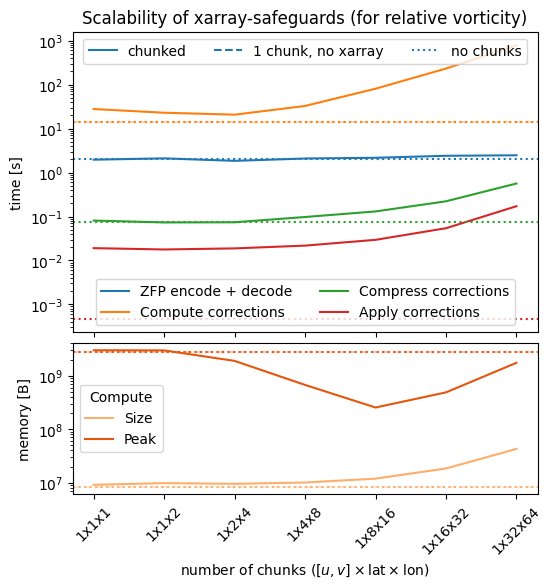

In [15]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(6, 6), height_ratios=[2, 1], gridspec_kw=dict(hspace=0.05)
)

(l1,) = ax1.plot([t["codec"] for t in timings], label="ZFP encode + decode")
(l2,) = ax1.plot([t["compute"] for t in timings], label="Compute corrections")
(l3,) = ax1.plot([t["compress"] for t in timings], label="Compress corrections")
(l4,) = ax1.plot([t["apply"] for t in timings], label="Apply corrections")

ax1.axhline(single_chunk_baseline["compute"], ls="--", c=l2.get_color(), alpha=1 / 3)

ax1.axhline(baseline["codec"], ls=":", c=l1.get_color())
ax1.axhline(baseline["compute"], ls=":", c=l2.get_color())
ax1.axhline(baseline["compress"], ls=":", c=l3.get_color())
ax1.axhline(baseline["apply"], ls=":", c=l4.get_color())

ax1.set_xticks(range(len(timings)))
ax1.set_xticklabels(
    [
        ""  # f"{t['chunks']['variable']}x{t['chunks']['latitude']}x{t['chunks']['longitude']}"
        for t in timings
    ],
    rotation=45,
)

l1 = ax1.legend(loc="lower center", ncol=2)
ax1.legend(
    handles=[
        mpl.lines.Line2D(
            [0],
            [0],
            color="tab:blue",
            ls="-",
            label="chunked",
        ),
        mpl.lines.Line2D(
            [0],
            [0],
            color="tab:blue",
            ls="--",
            label="1 chunk, no xarray",
        ),
        mpl.lines.Line2D(
            [0],
            [0],
            color="tab:blue",
            ls=":",
            label="no chunks",
        ),
    ],
    loc="upper center",
    ncol=3,
)
ax1.add_artist(l1)

ax1.set_yscale("log")
ax1.set_ylabel("time [s]")


(l1,) = ax2.plot(
    [t["compute-size"] for t in timings], c=mpl.cm.tab20c.colors[6], label="Size"
)
(l2,) = ax2.plot(
    [t["compute-peak"] for t in timings], c=mpl.cm.tab20c.colors[4], label="Peak"
)

ax2.axhline(
    single_chunk_baseline["compute-size"], ls="--", c=l1.get_color(), alpha=1 / 3
)
ax2.axhline(
    single_chunk_baseline["compute-peak"], ls="--", c=l2.get_color(), alpha=1 / 3
)

ax2.axhline(baseline["compute-size"], ls=":", c=l1.get_color())
ax2.axhline(baseline["compute-peak"], ls=":", c=l2.get_color())

ax2.set_xticks(range(len(timings)))
ax2.set_xticklabels(
    [
        f"{t['chunks']['variable']}x{t['chunks']['latitude']}x{t['chunks']['longitude']}"
        for t in timings
    ],
    rotation=45,
)

ax2.legend(loc="center left", title="Compute")

ax2.set_xlabel(r"number of chunks ($[u,v] \times \text{lat} \times \text{lon}$)")
ax2.set_yscale("log")
ax2.set_ylabel("memory [B]")

ax1.set_title("Scalability of xarray-safeguards (for relative vorticity)")

plt.show()